# ABDN EEG Fellowship
## Session 13: Full Preprocessing Pipeline
Raw EDF → Clean Epochs



---

### Where we are

In Sessions 11–12 you:
- Learned the BIDS structure
- Loaded your raw EDF file and visually inspected it
- Identified bad channels and dominant artifacts in your assignment

**Today:** we turn that raw file into clean epochs ready for analysis, we do so step by step, with every decision documented.

This notebook becomes your **master preprocessing script** for the rest of the fellowship

---

### Dataset reminder

| | Group 1 | Group 2 | Group 3 |
|---|---|---|---|
| **Subject** | S006 | S008 | S010 |
| **Run used** | R01 (baseline eyes open) | R04 (actual movement) | R05 (motor imagery) |
| **T0 means** | rest | rest | rest |
| **T1 means** | — | left fist movement | left fist imagery |
| **T2 means** | — | right fist movement | right fist imagery |

> ⚠️ **Important:** T1 and T2 mean different things in different runs. Always check your run number before interpreting events.

---

## Setup: run this first, every session

In [225]:
!pip install mne --quiet --upgrade moviepy jedi mne

import mne
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
mne.set_log_level('WARNING')
print(f'MNE version: {mne.__version__}')

MNE version: 1.12.1


---
## 📋 Step 0: Your Preprocessing Log

**Fill this in as you go.** Every decision you make gets recorded here.
At the end of today, this becomes your methods section draft.

```
PREPROCESSING LOG
=================
Subject ID       : S00X
Run number       : R0X
Task description :
Date processed   :
Processed by     :

Highpass filter  : ___ Hz
Lowpass filter   : ___ Hz
Notch filter     : ___ Hz
Reference        :
Bad channels     :
ICA components excluded :
Reason for exclusion    :
Epoch window     : ___ to ___ ms
Baseline window  : ___ to ___ ms
Rejection threshold     : ___ µV peak-to-peak
Epochs before rejection :
Epochs after rejection  :
Epochs retained (%)     :
Notes?:
```

---
## Step 1: Load your EDF file

In [226]:
# EDIT THIS BLOCK ─────────────────────────────────────────────────────────
# Replace with your subject and run

SUBJECT = 'S007'   # S006 / S008 / S010
RUN     = 'R04'    # R01 / R04 / R05

# If you have the file on Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# EDF_PATH = f'/content/drive/MyDrive/ABDN_EEG/{SUBJECT}/{SUBJECT}{RUN}.edf'


# Download directly from PhysioNet (if you don't have the file locally)
import urllib.request
import os

EDF_PATH = f'{SUBJECT}{RUN}.edf'
if not os.path.exists(EDF_PATH):
    url = f'https://physionet.org/files/eegmmidb/1.0.0/{SUBJECT}/{SUBJECT}{RUN}.edf'
    print(f'Downloading {SUBJECT}{RUN}.edf from PhysioNet...')
    urllib.request.urlretrieve(url, EDF_PATH)
    print('Download complete ✅')
else:
    print(f'File already exists: {EDF_PATH}')
# ─────────────────────────────────────────────────────────────────────────────

raw = mne.io.read_raw_edf(EDF_PATH, preload=True, verbose=False)

print(f'Subject : {SUBJECT}  |  Run: {RUN}')
print(f'Channels: {len(raw.ch_names)} ({raw.ch_names[:5]}...)')
print(f'Sampling rate: {raw.info["sfreq"]} Hz')
print(f'Duration: {raw.times[-1]:.1f} s  ({raw.times[-1]/60:.1f} min)')
print(f'Data shape: {raw.get_data().shape}  → (channels × time points)')

File already exists: S007R04.edf
Subject : S007  |  Run: R04
Channels: 64 (['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.']...)
Sampling rate: 160.0 Hz
Duration: 125.0 s  (2.1 min)
Data shape: (64, 20000)  → (channels × time points)


---
## Step 2: Channel setup: montage and bad channels

Channel names after cleaning:
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']

Montage set available!


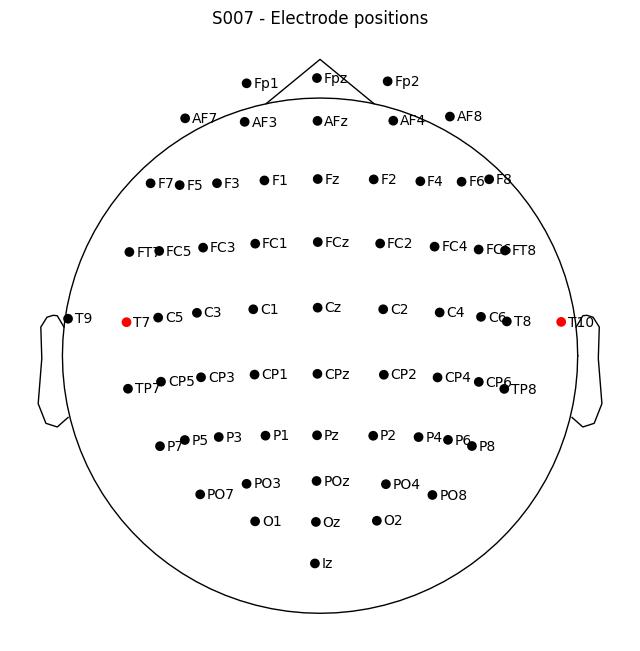

In [240]:
# The EEGMMIDB dataset uses the 10-10 system
# MNE can assign electrode positions automatically

# Rename channels to match MNE's standard 10-10 labels
# PhysioNet uses names like 'EEG Fc5.' we will clean those up

from mne.datasets import eegbci #Uncomment this line and the next one
eegbci.standardize(raw)

new_names = {}
for ch in raw.ch_names:
    # Strip 'EEG ' prefix and trailing '.' if present
    clean = ch.replace('EEG ', '').replace('.', '').strip()
    new_names[ch] = clean

raw.rename_channels(new_names)
print('Channel names after cleaning:')
print(raw.ch_names)

# Set the 10-10 standard montage
montage = mne.channels.make_standard_montage('standard_1005')
raw.set_montage(montage, on_missing='ignore', verbose=False)
print('\nMontage set available!')

# Visualise electrode positions
fig = raw.plot_sensors(show_names=True, kind='topomap', show=False)
fig.axes[0].set_title(f'{SUBJECT} - Electrode positions')
fig.savefig('electrode_positions.png', dpi=100, bbox_inches='tight')

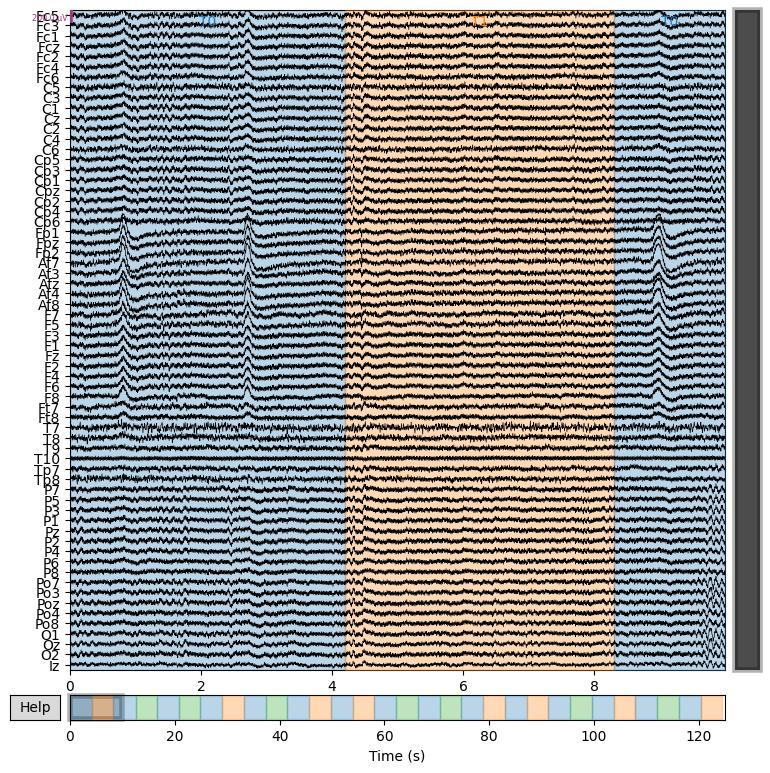

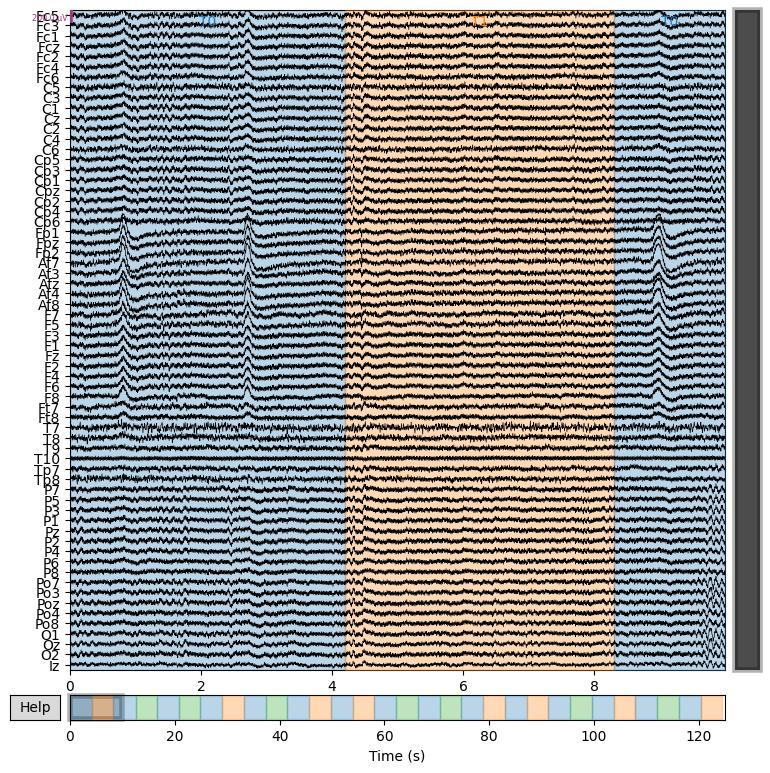

In [233]:
raw.plot(n_channels=64, duration=10, scalings=dict(eeg=100e-6), show=True)

In [241]:
# EDIT THIS BLOCK ─────────────────────────────────────────────────────────
# From your Session 12 quality report: which channels did you flag as bad?
# If you didn't find any, leave the list empty: []

BAD_CHANNELS = ['T7','T10']   # e.g. ['Fp1', 'AF3']  ← fill from your quality report

# ─────────────────────────────────────────────────────────────────────────────

raw.info['bads'] = BAD_CHANNELS

print(f'Bad channels marked: {raw.info["bads"]}')
print('These channels will be excluded from re-referencing and ICA.')
print('→ Log this in your preprocessing log above.')

Bad channels marked: ['T7', 'T10']
These channels will be excluded from re-referencing and ICA.
→ Log this in your preprocessing log above.


---
## Step 3: Filtering

### Why we filter
- **Highpass (1 Hz):** removes slow DC drift that makes the signal wander up and down
- **Lowpass (40 Hz):** removes high-frequency noise and muscle (EMG) artifact
- **Notch (60 Hz):** removes US electrical line noise (this dataset is US-recorded)

> ⚠️ **This dataset is sampled at 160 Hz** — Nyquist limit is 80 Hz, so lowpass at 40 Hz is safe and sensible.

Computing PSD before filtering...


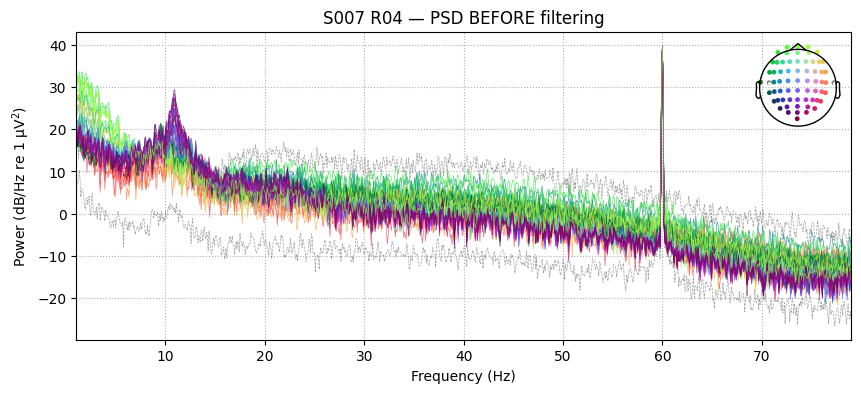

Saved: psd_before_filter.png


In [242]:
# Plot PSD BEFORE filtering so we can see what we're removing
print('Computing PSD before filtering...')
psd_before = raw.compute_psd(method='welch', fmin=1, fmax=79)
fig, ax = plt.subplots(figsize=(10, 4))
psd_before.plot(axes=ax, show=False)
ax.set_title(f'{SUBJECT} {RUN} — PSD BEFORE filtering')
plt.savefig('psd_before_filter.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: psd_before_filter.png')

Filtering applied:
  Bandpass : 1.0 – 40.0 Hz  (FIR, Hamming window)
  Notch    : 60 Hz



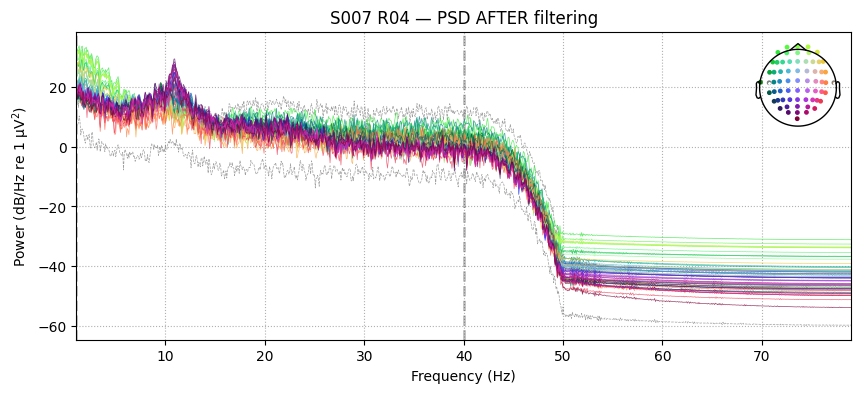

→ Compare before/after. The 60 Hz spike should be gone.
→ Log your filter choices in the preprocessing log.


In [243]:
# Apply filters
# We work on a copy to preserve the original raw object
raw_filt = raw.copy()

# Bandpass: 1–40 Hz (FIR, zero-phase — no temporal distortion)
raw_filt.filter(l_freq=1.0, h_freq=40.0, method='fir',
                fir_window='hamming', verbose=False)

# Notch at 60 Hz — US line noise
raw_filt.notch_filter(freqs=60, verbose=False)

print('Filtering applied:')
print('  Bandpass : 1.0 – 40.0 Hz  (FIR, Hamming window)')
print('  Notch    : 60 Hz')
print()

# Plot PSD AFTER filtering
psd_after = raw_filt.compute_psd(method='welch', fmin=1, fmax=79)
fig, ax = plt.subplots(figsize=(10, 4))
psd_after.plot(axes=ax, show=False)
ax.set_title(f'{SUBJECT} {RUN} — PSD AFTER filtering')
plt.savefig('psd_after_filter.png', dpi=100, bbox_inches='tight')
plt.show()

print('→ Compare before/after. The 60 Hz spike should be gone.')
print('→ Log your filter choices in the preprocessing log.')

---
## Step 4: Re-referencing

Every EEG signal is a *difference* between the active electrode and a reference.
The original recording uses whatever reference the BCI2000 system used (typically a single electrode).

We switch to **average reference**: subtract the mean of all channels from each channel.
This is standard for dense arrays (64 channels) and reduces reference electrode bias.

In [244]:
# Apply average reference
# Bad channels are automatically excluded from the average
raw_ref, _ = mne.set_eeg_reference(
    raw_filt,
    ref_channels='average',
    verbose=False
)

print('Re-referencing: average reference applied')
print(f'Bad channels excluded from average: {raw_ref.info["bads"]}')
print()
print('Why average reference?')
print('  - No single electrode is privileged as "zero"')
print('  - Works well when you have many channels (64+)')
print('  - Standard choice for scalp EEG research')
print()
print('Log reference choice in your preprocessing log.')

Re-referencing: average reference applied
Bad channels excluded from average: ['T7', 'T10']

Why average reference?
  - No single electrode is privileged as "zero"
  - Works well when you have many channels (64+)
  - Standard choice for scalp EEG research

Log reference choice in your preprocessing log.


---
## Step 5: ICA: removing eye and muscle artifacts

### What ICA does
ICA (Independent Component Analysis) mathematically separates the EEG into **independent sources**.
Some of these sources are neural, others are eye blinks, eye movements, heartbeat, or muscle noise.
We identify and remove the artifact sources, then reconstruct a cleaner signal.

### How to identify artifact components
| Artifact | Scalp topography | Waveform shape |
|---|---|---|
| Eye blink | Large frontal blob (Fp1/Fp2) | Slow regular bumps |
| Eye movement | Left/right dipole at front | Step-like deflections |
| Heartbeat | Widespread | Regular ~1 Hz spikes |
| Muscle | Focal, edge electrodes | High-frequency bursts |

> ⚠️ **ICA needs highpass-filtered data (≥ 1 Hz) to work well..which we already applied in Step 3**

In [245]:
from mne.preprocessing import ICA

# Fit ICA
# n_components: how many independent components to compute
# We use 20 -> enough to capture the main sources without overfitting
# random_state: fixing this makes the decomposition reproducible

print('Fitting ICA — this takes ~30–60 seconds...')

ica = ICA(
    n_components=20,
    method='fastica',
    random_state=42,
    max_iter=800
)

ica.fit(raw_ref, verbose=False)

print(f'ICA fitted: {ica.n_components_} components extracted sucessfully')

Fitting ICA — this takes ~30–60 seconds...
ICA fitted: 20 components extracted sucessfully


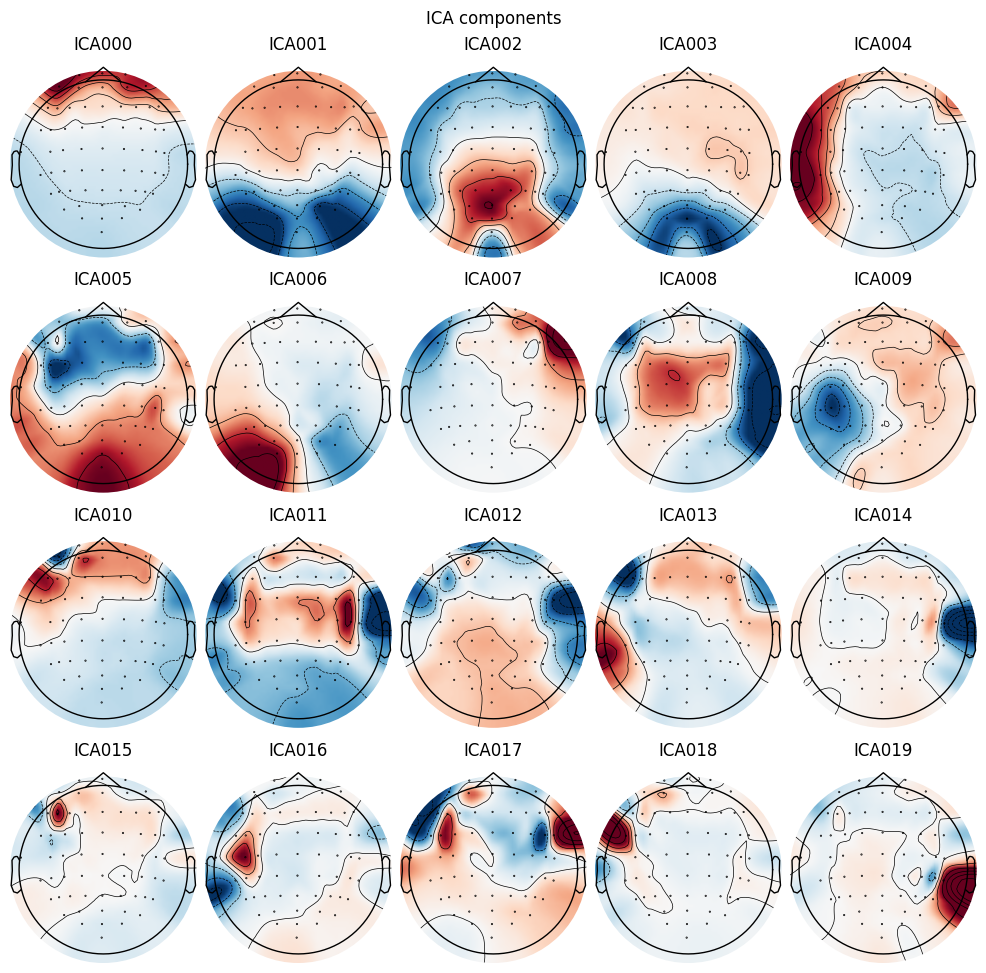


What to look for:
  - Strong frontal blob → likely eye blink
  - Left-right dipole at the front → eye movement
  - Diffuse/messy topography → noise or muscle
  - Clean dipolar topography → likely neural (keep it)


In [246]:
# Plot the scalp topography of each component
# This is the main tool for identifying artifact components

fig = ica.plot_components(picks=range(20), show=False)
plt.savefig('ica_topographies.png', dpi=100, bbox_inches='tight')
plt.show()
print()
print('What to look for:')
print('  - Strong frontal blob → likely eye blink')
print('  - Left-right dipole at the front → eye movement')
print('  - Diffuse/messy topography → noise or muscle')
print('  - Clean dipolar topography → likely neural (keep it)')

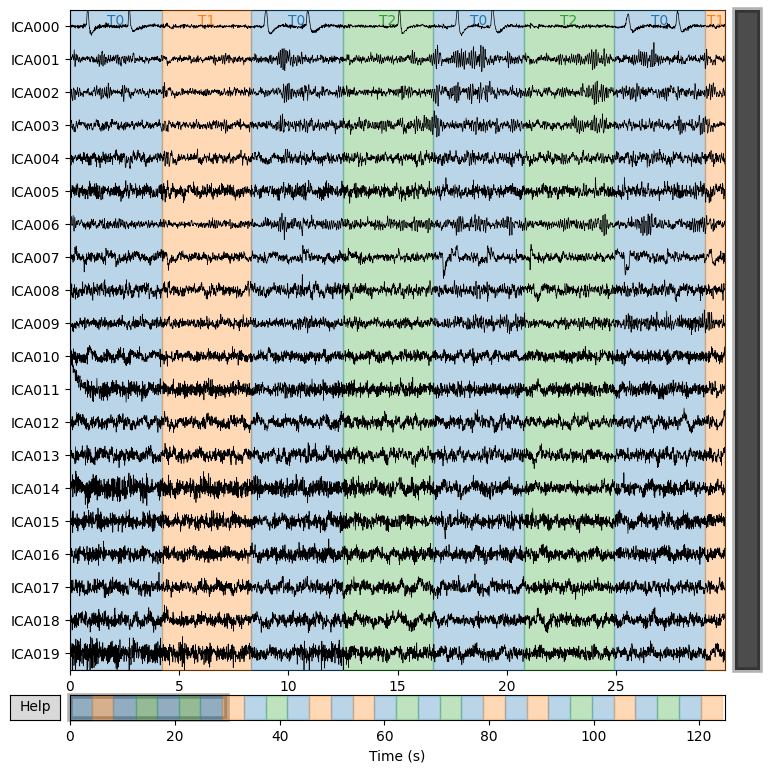

Saved: ica_timecourses.png

Look for:
  - Slow regular bumps (blinks) — should match your frontal topography component
  - Step-like deflections (eye movements)
  - High-frequency bursts (muscle)


In [247]:
# Plot the time course of each component
# This helps confirm what you identified from topographies

# Plot first 30 seconds
fig = ica.plot_sources(raw_ref, start=0, stop=30, show=False)
plt.savefig('ica_timecourses.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: ica_timecourses.png')
print()
print('Look for:')
print('  - Slow regular bumps (blinks) — should match your frontal topography component')
print('  - Step-like deflections (eye movements)')
print('  - High-frequency bursts (muscle)')

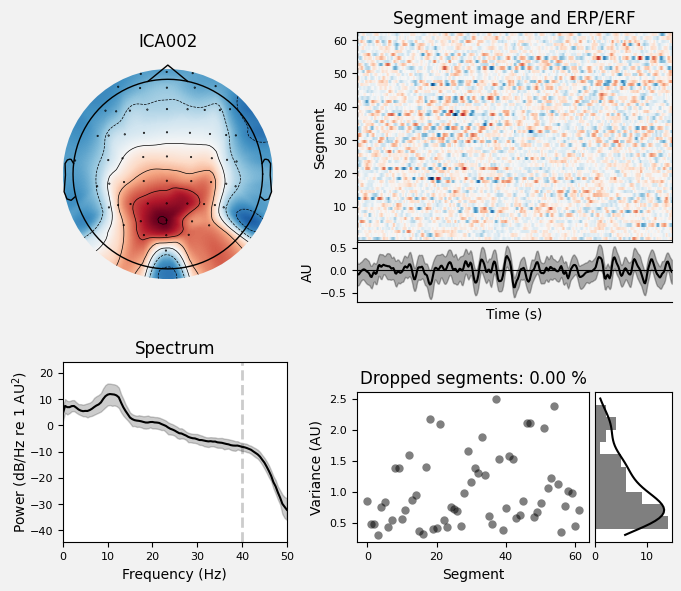

In [249]:
# Inspect individual components in detail
# Run this cell multiple times with different component indices

COMPONENT_TO_INSPECT = 2    # ← change this number (0, 1, 2, ...)

fig = ica.plot_properties(raw_ref, picks=[COMPONENT_TO_INSPECT], show=False)
plt.savefig(f'ica_component_{COMPONENT_TO_INSPECT:03d}.png',
            dpi=100, bbox_inches='tight')
plt.show()

# The properties plot shows:
# - Topography (top left)
# - Time course sample
# - Power spectrum
# - Epoch image showing trial-by-trial consistency

In [252]:
# EDIT THIS BLOCK ─────────────────────────────────────────────────────────
# After inspecting the components above, list the ones to exclude
# Conservative approach: only exclude if you are SURE it is artifact
# When in doubt, leave it in — removing neural components is worse than leaving noise

ICA_EXCLUDE = [0, 4, 7]  # ← replace with your actual artifact component indices
ICA_EXCLUDE_REASON = [
    'IC000: frontal topography, slow blink-like waveform → eye blink',
    'IC004: muscle movement',
    'IC007: eye defliction',
]  # ← one reason per excluded component

# ─────────────────────────────────────────────────────────────────────────────

ica.exclude = ICA_EXCLUDE

print(f'Components marked for exclusion: {ICA_EXCLUDE}')
for idx, reason in zip(ICA_EXCLUDE, ICA_EXCLUDE_REASON):
    print(f'  IC{idx:03d}: {reason}')
print()
print('→ Log component indices and reasons in your preprocessing log.')

Components marked for exclusion: [0, 4, 7]
  IC000: IC000: frontal topography, slow blink-like waveform → eye blink
  IC004: IC004: muscle movement
  IC007: IC007: eye defliction

→ Log component indices and reasons in your preprocessing log.


ICA applied: removed 3 component(s)!!



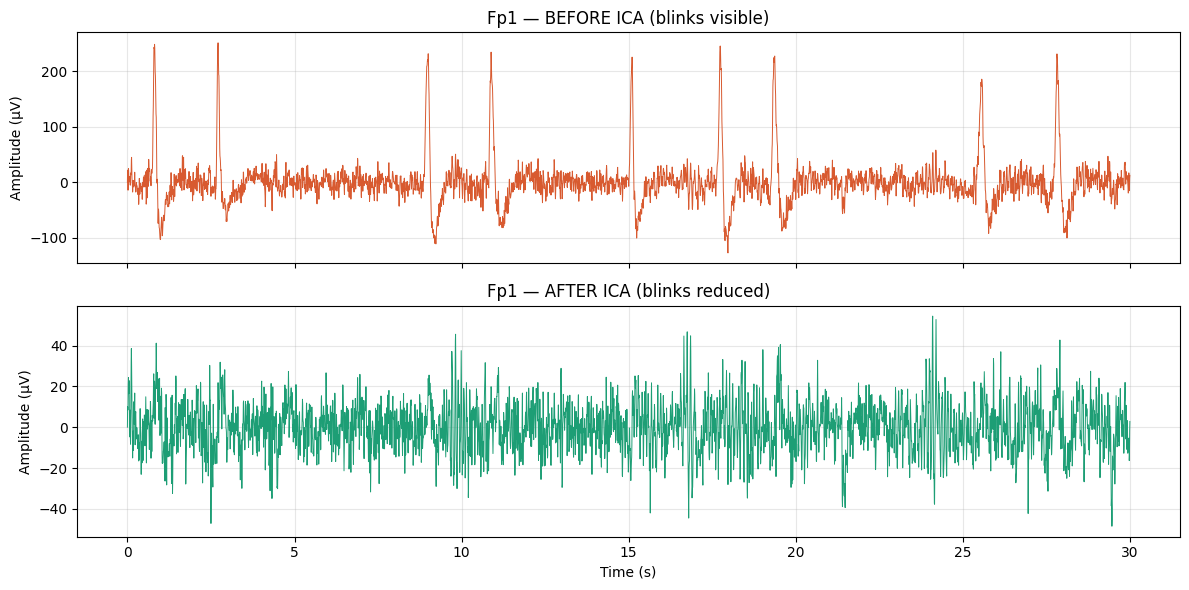

Saved: ica_before_after.png

If ICA worked correctly: large slow deflections (blinks) are gone or much smaller.
The underlying EEG rhythms should be preserved.


In [253]:
# Apply ICA: reconstruct signal without the artifact components
raw_clean = raw_ref.copy()
ica.apply(raw_clean, verbose=False)

print(f'ICA applied: removed {len(ica.exclude)} component(s)!!')
print()

# Visual check: compare before and after ICA on frontal channel
# Blinks should be dramatically reduced
sfreq = raw_clean.info['sfreq']
t0, t1 = int(0 * sfreq), int(30 * sfreq)

# Find a frontal channel (Fp1 or first channel)
frontal_ch = 'Fp1' if 'Fp1' in raw_clean.ch_names else raw_clean.ch_names[0]
ch_idx = raw_clean.ch_names.index(frontal_ch)

data_before = raw_ref.get_data()[ch_idx, t0:t1] * 1e6
data_after  = raw_clean.get_data()[ch_idx, t0:t1] * 1e6
t_seg       = raw_clean.times[t0:t1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(t_seg, data_before, color='#D85A30', linewidth=0.7)
ax1.set_ylabel('Amplitude (µV)')
ax1.set_title(f'{frontal_ch} — BEFORE ICA (blinks visible)')
ax1.grid(True, alpha=0.3)

ax2.plot(t_seg, data_after, color='#1D9E75', linewidth=0.7)
ax2.set_ylabel('Amplitude (µV)')
ax2.set_xlabel('Time (s)')
ax2.set_title(f'{frontal_ch} — AFTER ICA (blinks reduced)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ica_before_after.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: ica_before_after.png')
print()
print('If ICA worked correctly: large slow deflections (blinks) are gone or much smaller.')
print('The underlying EEG rhythms should be preserved.')

---
## Step 6: Extract Events and Epoch

Events in this dataset are stored as **annotations** in the EDF file (T0, T1, T2).
We convert these to MNE events and cut the continuous signal into **epochs**, short segments around each event.

In [266]:
# Extract events from annotations
events, event_id_raw = mne.events_from_annotations(raw_clean, verbose=False)
# picks = mne.pick_types(raw_clean.info, eeg=True, exclude='bads')

print(f'Events found: {len(events)}')
print(f'Event types: {event_id_raw}')
print()
print('Counts per event type:')
for name, eid in event_id_raw.items():
    count = (events[:, 2] == eid).sum()
    print(f'  {name}: {count} events')
print()

# Re-map to meaningful labels based on the run
# Run R01 (baseline): only T0 = rest, no task events
# Run R04 (real movement): T0=rest, T1=left fist, T2=right fist
# Run R05 (imagery): T0=rest, T1=left imagery, T2=right imagery

if RUN == 'R01':
    event_id = {'rest/T0': event_id_raw.get('T0', 1)}
    print('Baseline run (R01): only rest (T0) events')
elif RUN == 'R04':
    event_id = {
        'rest/T0':            event_id_raw.get('T0', 1),
        'movement/left_fist': event_id_raw.get('T1', 2),
        'movement/right_fist':event_id_raw.get('T2', 3),
    }
    print('Movement run (R04): T1=left fist, T2=right fist')
elif RUN == 'R05':
    event_id = {
        'rest/T0':            event_id_raw.get('T0', 1),
        'imagery/left_fist':  event_id_raw.get('T1', 2),
        'imagery/right_fist': event_id_raw.get('T2', 3),
    }
    print('Imagery run (R05): T1=left fist imagery, T2=right fist imagery')
else:
    event_id = event_id_raw
    print(f'Unknown run {RUN}: using raw event labels')

# Remove any event IDs not found in the data
event_id = {k: v for k, v in event_id.items() if v in events[:, 2]}
print(f'\nFinal event mapping: {event_id}')

Events found: 30
Event types: {np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

Counts per event type:
  T0: 15 events
  T1: 8 events
  T2: 7 events

Movement run (R04): T1=left fist, T2=right fist

Final event mapping: {'rest/T0': 1, 'movement/left_fist': 2, 'movement/right_fist': 3}


In [274]:
# EDIT THIS BLOCK ─────────────────────────────────────────────────────────
# Epoch parameters — these are your analysis decisions

TMIN      = -1.0   # seconds before event onset (baseline starts here)
TMAX      =  3.0   # seconds after event onset (task period is ~4s in this dataset)
BASELINE  = (-1.0, 0.0)  # baseline correction window (pre-stimulus)

# Rejection threshold: any epoch with peak-to-peak amplitude > this gets removed
# 150 µV is a common starting point; lower = stricter, higher = more lenient
REJECT_THRESHOLD_UV = 210
REJECT = {'eeg': REJECT_THRESHOLD_UV * 1e-6}  # convert µV to Volts for MNE

# ─────────────────────────────────────────────────────────────────────────────

n_events_before = len(events)

epochs = mne.Epochs(
    raw_clean,
    events,
    event_id=event_id,
    tmin=TMIN,
    tmax=TMAX,
    baseline=BASELINE,
    reject=REJECT,
    preload=True,
    verbose=False
)

n_kept = len(epochs)
pct_kept = 100 * n_kept / n_events_before if n_events_before > 0 else 0

print(f'Epoching complete:')
print(f'  Window       : {TMIN} to {TMAX} s')
print(f'  Baseline     : {BASELINE[0]} to {BASELINE[1]} s')
print(f'  Reject thresh: {REJECT_THRESHOLD_UV} µV')
print(f'  Epochs kept  : {n_kept} / {n_events_before}  ({pct_kept:.1f}%)')
print()
print('Condition breakdown:')
for cond in event_id:
    if cond in epochs.event_id:
        n = len(epochs[cond])
        print(f'  {cond}: {n} epochs')
print()
print('Log epoch counts and rejection threshold in your preprocessing log.')

Epoching complete:
  Window       : -1.0 to 3.0 s
  Baseline     : -1.0 to 0.0 s
  Reject thresh: 210 µV
  Epochs kept  : 24 / 30  (80.0%)

Condition breakdown:
  rest/T0: 10 epochs
  movement/left_fist: 7 epochs
  movement/right_fist: 7 epochs

Log epoch counts and rejection threshold in your preprocessing log.


In [275]:
print(f'Total events found     : {len(events)}')
print(f'Event id map            : {event_id}')
print(f'Epochs kept              : {len(epochs)}')
print()
print('Drop log (why each epoch was dropped):')
print(epochs.drop_log)

Total events found     : 30
Event id map            : {'rest/T0': 1, 'movement/left_fist': 2, 'movement/right_fist': 3}
Epochs kept              : 24

Drop log (why each epoch was dropped):
(('NO_DATA',), (), (), (), (), (), (), (), (), (), (), (), ('C5',), (), (), (), ('O1',), (), ('PO7', 'PO3', 'POz', 'O1', 'Oz', 'O2'), (), (), (), ('O1',), (), (), ('O1', 'Oz'), (), (), (), ())


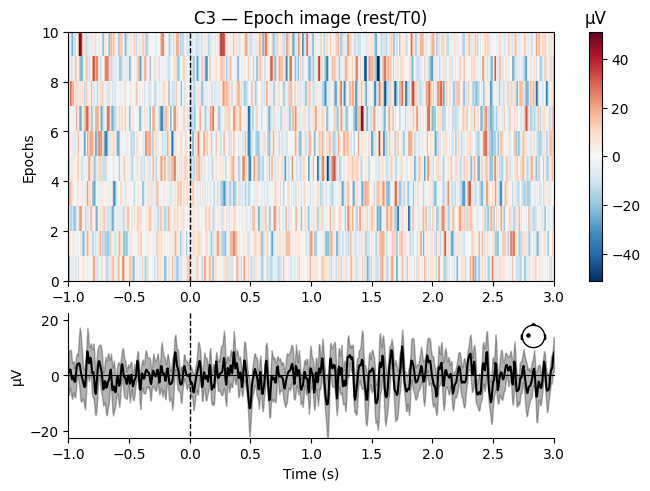


Each horizontal line = one epoch.
Red = positive, blue = negative.
Bright horizontal stripes across many epochs = remaining artifact → consider lowering threshold.
Random variation is fine — that is neural activity.


In [276]:
# Quick check: plot the epoch image
# This shows all epochs stacked,, good for spotting remaining artifacts

# Use the first available condition
first_cond = list(epochs.event_id.keys())[0]
ch_to_plot = 'C3' if 'C3' in epochs.ch_names else epochs.ch_names[10]

figs = epochs[first_cond].plot_image(
    picks=ch_to_plot,
    show=False
)
fig = figs[0]
fig.axes[0].set_title(f'{ch_to_plot} — Epoch image ({first_cond})')
fig.savefig('epoch_image.png', dpi=100, bbox_inches='tight')
plt.show()

print()
print('Each horizontal line = one epoch.')
print('Red = positive, blue = negative.')
print('Bright horizontal stripes across many epochs = remaining artifact → consider lowering threshold.')
print('Random variation is fine — that is neural activity.')


---
## Step 7: Save clean epochs

In [277]:
# Save epochs as a .fif file (MNE's native format)
# This is what you'll load in Sessions 14, 15, 16

OUTPUT_PATH = f'{SUBJECT}_{RUN}_clean_epo.fif'
epochs.save(OUTPUT_PATH, overwrite=True, verbose=False)

print(f'Epochs saved → {OUTPUT_PATH}')
print()

# Verify we can reload it
epochs_check = mne.read_epochs(OUTPUT_PATH, preload=False, verbose=False)
print(f'Reload check: {len(epochs_check)} epochs, {len(epochs_check.ch_names)} channels')

Epochs saved → S007_R04_clean_epo.fif

Reload check: 24 epochs, 64 channels


---
## Discussion (10 min)

Go through these questions as a group. There are no right answers, our goal is to understand the trade-offs.

In [278]:
# Share your epoch counts with the class
# We'll compare across groups to start the discussion

print('=== Share with the class ===')
print(f'Your subject    : {SUBJECT}')
print(f'Your run        : {RUN}')
print(f'Bad channels    : {raw_clean.info["bads"]}')
print(f'ICA excluded    : {ica.exclude}')
print(f'Reject threshold: {REJECT_THRESHOLD_UV} µV')
print(f'Epochs retained : {len(epochs)} / {n_events_before}  ({pct_kept:.1f}%)')
for cond in event_id:
    if cond in epochs.event_id:
        print(f'  {cond}: {len(epochs[cond])}')

=== Share with the class ===
Your subject    : S007
Your run        : R04
Bad channels    : ['T7', 'T10']
ICA excluded    : [0, 4, 7]
Reject threshold: 210 µV
Epochs retained : 24 / 30  (80.0%)
  rest/T0: 10
  movement/left_fist: 7
  movement/right_fist: 7


### Discussion questions

**Q1) Why did groups end up with different epoch counts?**

Think about: different subjects, different runs, different ICA choices, different rejection thresholds.
Is this a problem? What matters for analysis?

*(Write your answer here as a comment)*

---

**Q2) How aggressive should artifact rejection be?**

Two students:
- Student A rejected at 100 µV → kept 60 epochs per condition
- Student B rejected at 200 µV → kept 95 epochs per condition

Student B has more epochs but noisier data. Student A has cleaner data but fewer epochs (less statistical power).
What would you choose, and why?

*(Write your answer here)*

---

**Q3) What must always be documented, and where?**

Imagine reading another lab's paper. What preprocessing details do you need to know
to judge whether their analysis is trustworthy? Where should those details appear?

*(Hint: methods section, preprocessing log, notebook comments — all three)*

---

**Q4) Read this methods section extract. What's missing?**

> *"EEG data were preprocessed using MNE-Python. Data were filtered and epoched around task events. Artifact-contaminated epochs were removed."*

List everything the reader cannot reproduce from this description.

*(Write your answer here)*

---
## Assignment

Due 1 Septemper 23:59 AoE:

1. **Run this full pipeline on your assigned subject**, every cell, top to bottom, no skipping
2. **Fill in your preprocessing log** at the top of this notebook
3. **Write a 150-word preprocessing description** in the cell below, as if writing for a methods section of a paper. Include:
   - Filter settings (highpass, lowpass, notch)
   - Re-referencing scheme
   - ICA: how many components fitted, how many excluded, and why
   - Epoch window, baseline, rejection threshold
   - Final epoch counts per condition

4. **Save your clean epochs** (.fif file) to Google Drive, you will need them for upcoming sessions

---
## Summary: The full pipeline at a glance

```
raw EDF
  │
  ├─ 1. LOAD         mne.io.read_raw_edf()
  ├─ 2. CHANNELS     rename + set_montage() + mark bads
  ├─ 3. FILTER       .filter(1, 40) + .notch_filter(60)
  ├─ 4. REFERENCE    set_eeg_reference('average')
  ├─ 5. ICA          fit → inspect → exclude → apply
  ├─ 6. EPOCH        events_from_annotations() → Epochs()
  └─ 7. SAVE         epochs.save('*_epo.fif')
```

**Upcoming sessions:** we load these clean epochs and compute power spectra, the Fourier transform and what it tells us about which brain rhythms are active.

---
*ABDN EEG Fellowship 2026 · Session 13 · TA: Nada*